# Perbandingan Metode Fuzzy Mamdani dan Sugeno untuk Estimasi Harga Properti
**Dataset:** [Zameen Dataset](https://www.kaggle.com/datasets/jillanisofttech/pakistan-house-price-dataset)

## 1. Import Modul Standar

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

## 2. Persiapan Data dan Fungsi Keanggotaan

In [ ]:
df = pd.read_csv('zameen-updated-sample50k.csv')
df = df.dropna(subset=['price', 'Area Size', 'Area Type', 'bedrooms', 'baths', 'property_type', 'city'])

# Input 1: Konversi Area ke Marla
def convert_to_marla(row):
    if row['Area Type'] == 'Kanal':
        return row['Area Size'] * 20
    return row['Area Size']
df['Area_Marla'] = df.apply(convert_to_marla, axis=1)

# Batasan harga: Minimum 1.000 dan Maksimum 2.250.000 PKR
df = df[(df['price'] >= 1000) & (df['price'] <= 2.25e6)]

# Input 4: Ekstrak Skor Tipe Properti (Skala 1 - 10)
def get_property_score(ptype):
    ptype = str(ptype).lower()
    if 'farm' in ptype or 'penthouse' in ptype: return 10
    elif 'house' in ptype: return 8
    elif 'flat' in ptype or 'apartment' in ptype: return 6
    else: return 3
df['Property_Score'] = df['property_type'].apply(get_property_score)

# Input 5: Ekstrak Skor Lokasi/Kota (Skala 1 - 100)
def get_location_score(city):
    city = str(city).lower()
    if 'islamabad' in city: return 90
    elif 'lahore' in city or 'karachi' in city: return 80
    elif 'rawalpindi' in city or 'faisalabad' in city: return 60
    else: return 40
df['Location_Score'] = df['city'].apply(get_location_score)

def trapmf(x, abcd):
    a, b, c, d = abcd
    y = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= a or x[i] >= d: 
            y[i] = 0.0
        elif a < x[i] < b: 
            y[i] = (x[i] - a) / (b - a) if b != a else 1.0
        elif b <= x[i] <= c: 
            y[i] = 1.0
        elif c < x[i] < d: 
            y[i] = (d - x[i]) / (d - c) if d != c else 1.0
    return y

def trimf(x, abc):
    a, b, c = abc
    return trapmf(x, [a, b, b, c])

def fuzzify_area(x): return {'Kecil': trapmf([x], [0, 0, 8, 15])[0], 'Sedang': trimf([x], [10, 20, 30])[0], 'Luas': trapmf([x], [20, 40, 160, 160])[0]}
def fuzzify_bed(x): return {'Sedikit': trapmf([x], [0, 0, 2, 5])[0], 'Sedang': trimf([x], [3, 5, 8])[0], 'Banyak': trapmf([x], [6, 9, 28, 28])[0]}
def fuzzify_bath(x): return {'Sedikit': trapmf([x], [0, 0, 2, 4])[0], 'Sedang': trimf([x], [3, 5, 7])[0], 'Banyak': trapmf([x], [6, 8, 14, 14])[0]}
def fuzzify_prop(x): return {'Sederhana': trapmf([x], [0, 0, 3, 5])[0], 'Menengah': trimf([x], [4, 6, 8])[0], 'Mewah': trapmf([x], [7, 9, 10, 10])[0]}
def fuzzify_loc(x): return {'Biasa': trapmf([x], [0, 0, 40, 50])[0], 'Strategis': trimf([x], [40, 65, 85])[0], 'Sangat Strategis': trapmf([x], [80, 90, 100, 100])[0]}

C:\Users\voliya\AppData\Local\Temp\ipykernel_6896\1981301414.py:1: DtypeWarning: Columns (0: page_url, 1: property_type, 2: location, 3: city, 4: province_name, 5: area, 6: purpose, 7: date_added, 8: agency, 9: agent, 10: Area Type, 11: Area Category) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('zameen-updated-sample50k.csv')


### Visualisasi Membership Functions

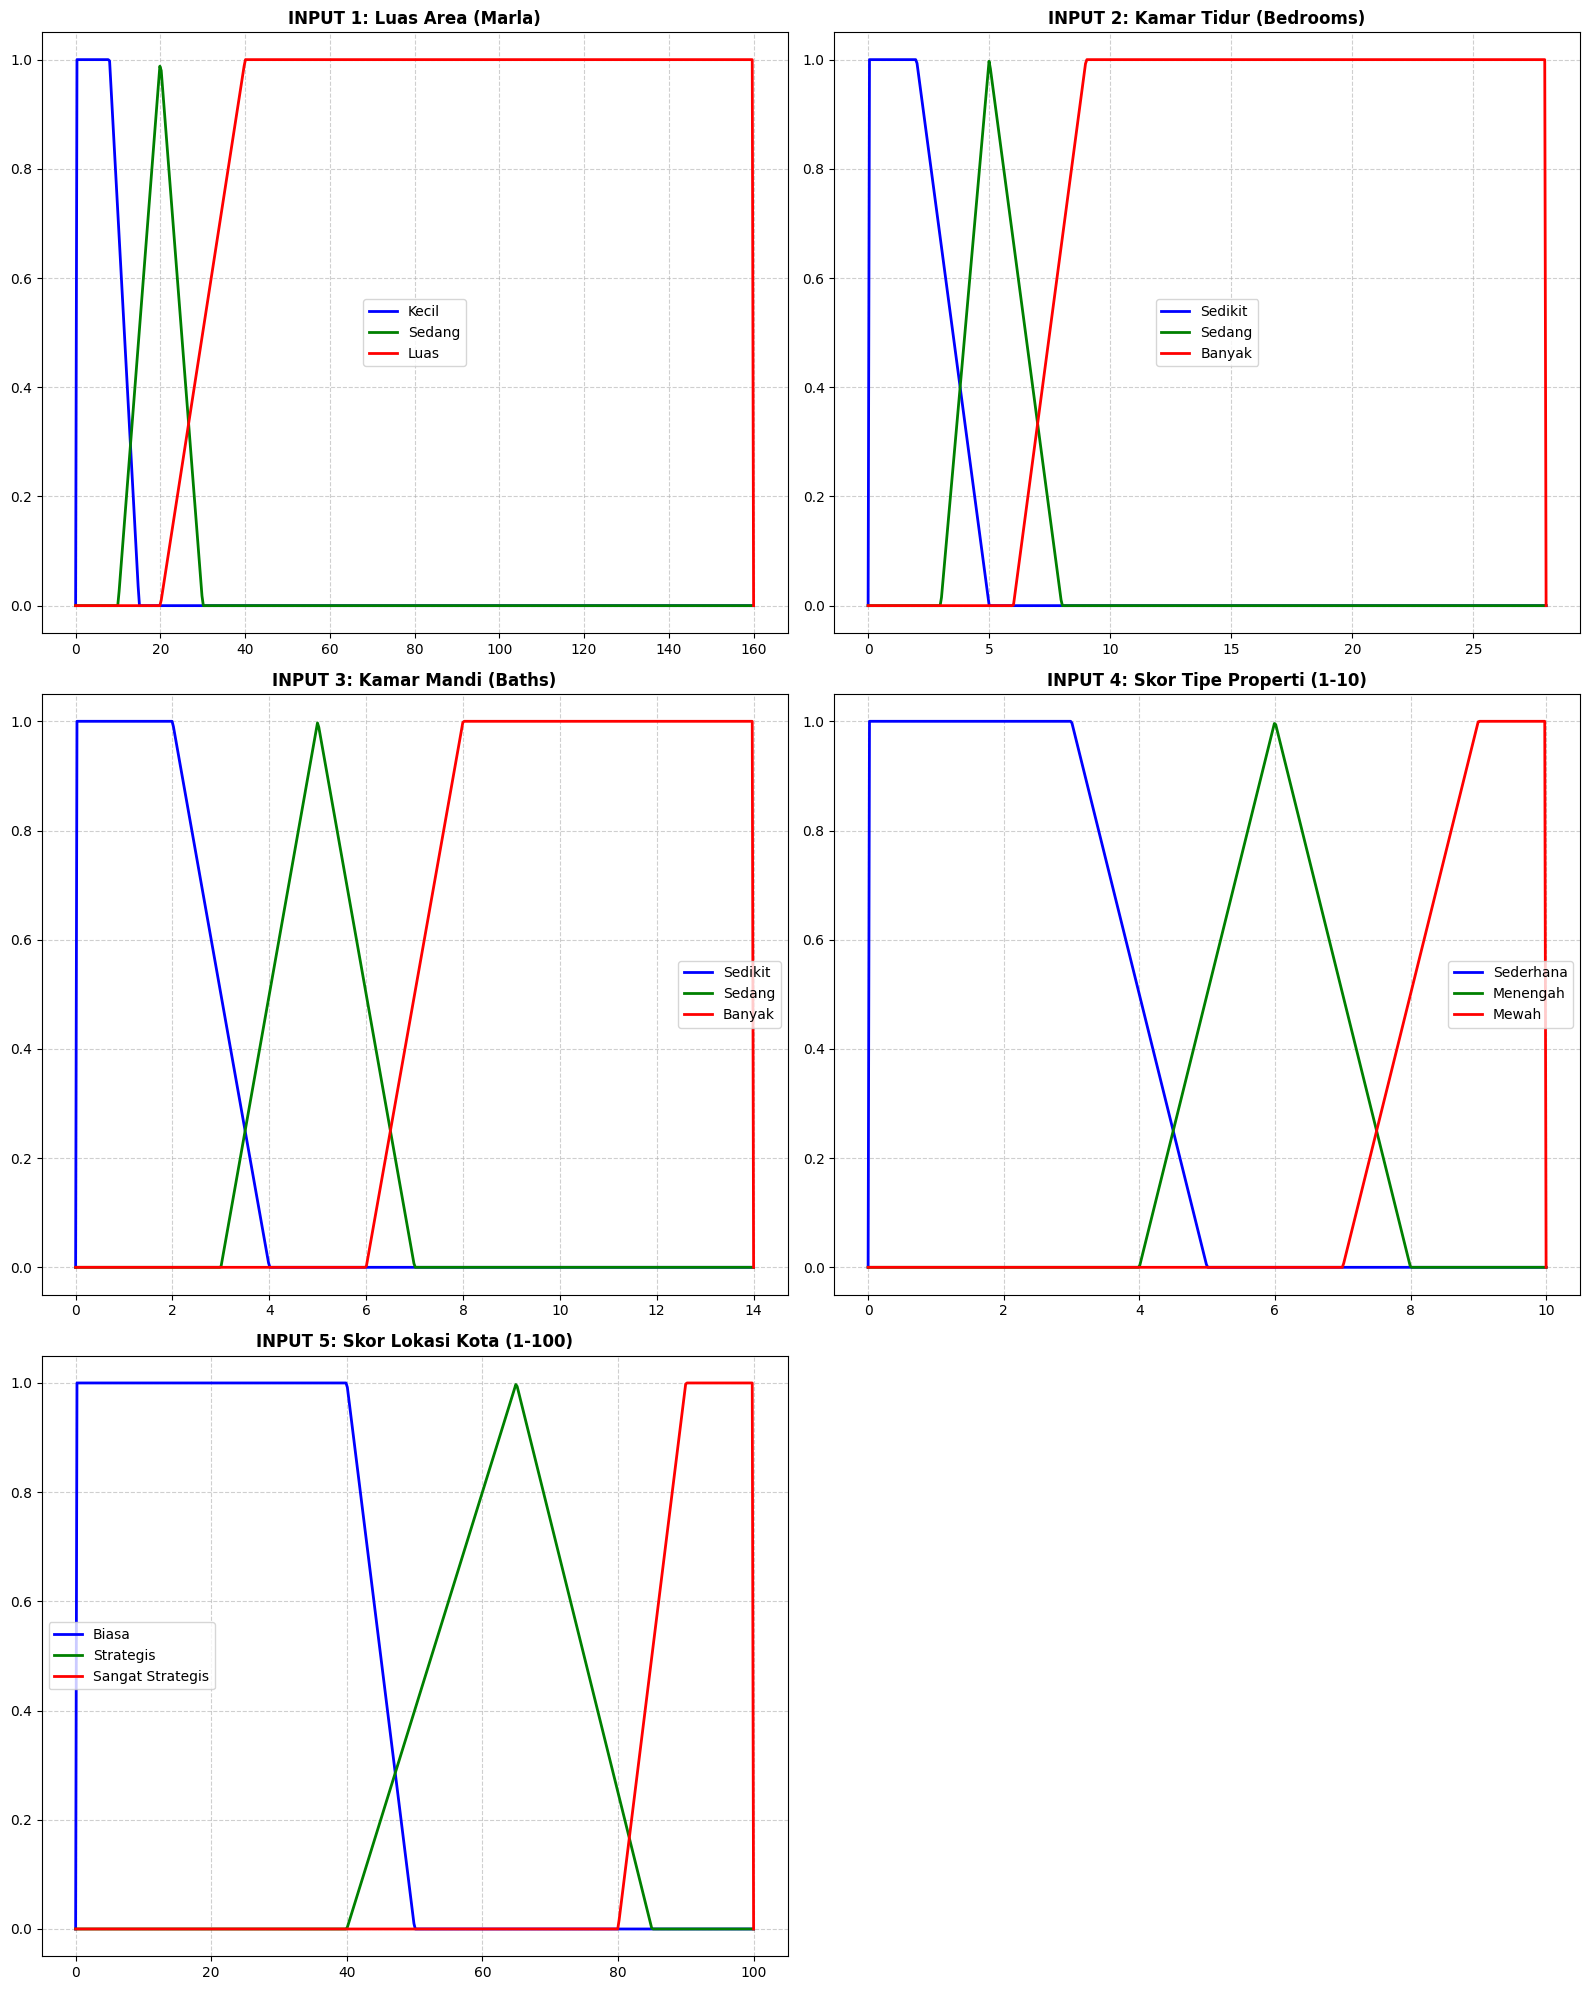

In [15]:
def plot_membership_functions():
    fig, axs = plt.subplots(3, 2, figsize=(16, 20))
    plt.subplots_adjust(hspace=0.4, wspace=0.2)

    # 1. Plot Area
    x_area = np.linspace(0, 160, 500)
    axs[0, 0].plot(x_area, trapmf(x_area, [0, 0, 8, 15]), label='Kecil', color='blue', linewidth=2)
    axs[0, 0].plot(x_area, trimf(x_area, [10, 20, 30]), label='Sedang', color='green', linewidth=2)
    axs[0, 0].plot(x_area, trapmf(x_area, [20, 40, 160, 160]), label='Luas', color='red', linewidth=2)
    axs[0, 0].set_title('INPUT 1: Luas Area (Marla)', fontsize=12, fontweight='bold')
    axs[0, 0].legend(); axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    # 2. Plot Bedrooms
    x_bed = np.linspace(0, 28, 500)
    axs[0, 1].plot(x_bed, trapmf(x_bed, [0, 0, 2, 5]), label='Sedikit', color='blue', linewidth=2)
    axs[0, 1].plot(x_bed, trimf(x_bed, [3, 5, 8]), label='Sedang', color='green', linewidth=2)
    axs[0, 1].plot(x_bed, trapmf(x_bed, [6, 9, 28, 28]), label='Banyak', color='red', linewidth=2)
    axs[0, 1].set_title('INPUT 2: Kamar Tidur (Bedrooms)', fontsize=12, fontweight='bold')
    axs[0, 1].legend(); axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    # 3. Plot Baths
    x_bath = np.linspace(0, 14, 500)
    axs[1, 0].plot(x_bath, trapmf(x_bath, [0, 0, 2, 4]), label='Sedikit', color='blue', linewidth=2)
    axs[1, 0].plot(x_bath, trimf(x_bath, [3, 5, 7]), label='Sedang', color='green', linewidth=2)
    axs[1, 0].plot(x_bath, trapmf(x_bath, [6, 8, 14, 14]), label='Banyak', color='red', linewidth=2)
    axs[1, 0].set_title('INPUT 3: Kamar Mandi (Baths)', fontsize=12, fontweight='bold')
    axs[1, 0].legend(); axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    # 4. Plot Property Score
    x_prop = np.linspace(0, 10, 500)
    axs[1, 1].plot(x_prop, trapmf(x_prop, [0, 0, 3, 5]), label='Sederhana', color='blue', linewidth=2)
    axs[1, 1].plot(x_prop, trimf(x_prop, [4, 6, 8]), label='Menengah', color='green', linewidth=2)
    axs[1, 1].plot(x_prop, trapmf(x_prop, [7, 9, 10, 10]), label='Mewah', color='red', linewidth=2)
    axs[1, 1].set_title('INPUT 4: Skor Tipe Properti (1-10)', fontsize=12, fontweight='bold')
    axs[1, 1].legend(); axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    # 5. Plot Location Score
    x_loc = np.linspace(0, 100, 500)
    axs[2, 0].plot(x_loc, trapmf(x_loc, [0, 0, 40, 50]), label='Biasa', color='blue', linewidth=2)
    axs[2, 0].plot(x_loc, trimf(x_loc, [40, 65, 85]), label='Strategis', color='green', linewidth=2)
    axs[2, 0].plot(x_loc, trapmf(x_loc, [80, 90, 100, 100]), label='Sangat Strategis', color='red', linewidth=2)
    axs[2, 0].set_title('INPUT 5: Skor Lokasi Kota (1-100)', fontsize=12, fontweight='bold')
    axs[2, 0].legend(); axs[2, 0].grid(True, linestyle='--', alpha=0.6)

    # Sembunyikan grid kosong
    axs[2, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Memanggil fungsi plot visualisasi
plot_membership_functions()

## 3. Evaluasi Rules

In [16]:
def eval_rules(f_area, f_bed, f_bath, f_prop, f_loc):
    rules = []
    
    # --- KELOMPOK 1: Area Kecil (5 Rules) ---
    rules.append( (min(f_area['Kecil'], f_bed['Sedikit'], f_bath['Sedikit'], f_prop['Sederhana'], f_loc['Biasa']), 'Sangat Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Sedikit'], f_prop['Sederhana'], f_loc['Strategis']), 'Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Sedang'], f_bath['Sedikit'], f_prop['Menengah']), 'Murah') )
    rules.append( (min(f_area['Kecil'], f_bed['Banyak'], f_prop['Menengah'], f_loc['Biasa']), 'Sedang') )
    rules.append( (min(f_area['Kecil'], f_prop['Mewah'], f_loc['Sangat Strategis']), 'Sedang') )

    # --- KELOMPOK 2: Area Sedang (6 Rules) ---
    rules.append( (min(f_area['Sedang'], f_bed['Sedikit'], f_bath['Sedikit'], f_prop['Sederhana']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_bath['Sedikit'], f_loc['Biasa']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_bath['Sedang'], f_prop['Menengah'], f_loc['Strategis']), 'Sedang') )
    rules.append( (min(f_area['Sedang'], f_bed['Banyak'], f_bath['Sedang'], f_prop['Menengah']), 'Sedang') )
    rules.append( (min(f_area['Sedang'], f_bed['Sedang'], f_prop['Mewah'], f_loc['Strategis']), 'Mahal') )
    rules.append( (min(f_area['Sedang'], f_bed['Banyak'], f_bath['Banyak'], f_loc['Sangat Strategis']), 'Mahal') )

    # --- KELOMPOK 3: Area Luas (6 Rules) ---
    rules.append( (min(f_area['Luas'], f_bed['Sedikit'], f_prop['Sederhana'], f_loc['Biasa']), 'Sedang') )
    rules.append( (min(f_area['Luas'], f_bed['Sedikit'], f_prop['Menengah'], f_loc['Strategis']), 'Sedang') )
    rules.append( (min(f_area['Luas'], f_bed['Sedang'], f_bath['Sedikit'], f_prop['Menengah']), 'Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Sedang'], f_bath['Sedang'], f_prop['Mewah'], f_loc['Strategis']), 'Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Banyak'], f_bath['Sedang'], f_prop['Mewah']), 'Sangat Mahal') )
    rules.append( (min(f_area['Luas'], f_bed['Banyak'], f_bath['Banyak'], f_prop['Menengah'], f_loc['Sangat Strategis']), 'Sangat Mahal') )

    # --- KELOMPOK 4: Kombinasi Silang / Kasus Ekstrem (3 Rules) ---
    rules.append( (min(f_prop['Mewah'], f_loc['Sangat Strategis'], f_bath['Banyak']), 'Sangat Mahal') )
    rules.append( (min(f_prop['Sederhana'], f_loc['Biasa'], f_bed['Banyak']), 'Murah') )
    rules.append( (min(f_area['Sedang'], f_prop['Mewah'], f_bath['Banyak']), 'Mahal') )

    agg = {'Sangat Murah': 0.0, 'Murah': 0.0, 'Sedang': 0.0, 'Mahal': 0.0, 'Sangat Mahal': 0.0}
    for w, out in rules:
        agg[out] = max(agg[out], w)
    return agg

## 4. Defuzzifikasi Mamdani & Sugeno

In [17]:
z_points = np.linspace(0, 2.25e6, 2251)

def mf_price(x, category):
    val = [x]
    if category == 'Sangat Murah': return trapmf(val, [0, 0, 3e5, 6e5])[0]
    elif category == 'Murah': return trimf(val, [4e5, 8e5, 1.2e6])[0]
    elif category == 'Sedang': return trimf(val, [1e6, 1.4e6, 1.8e6])[0]
    elif category == 'Mahal': return trimf(val, [1.5e6, 1.8e6, 2.1e6])[0]
    elif category == 'Sangat Mahal': return trapmf(val, [1.9e6, 2.25e6, 2.25e6, 2.25e6])[0]

def defuzz_mamdani_manual(agg):
    num = 0.0
    den = 0.0
    for z in z_points:
        mu = max(
            min(agg['Sangat Murah'], mf_price(z, 'Sangat Murah')),
            min(agg['Murah'], mf_price(z, 'Murah')),
            min(agg['Sedang'], mf_price(z, 'Sedang')),
            min(agg['Mahal'], mf_price(z, 'Mahal')),
            min(agg['Sangat Mahal'], mf_price(z, 'Sangat Mahal'))
        )
        num += z * mu
        den += mu
        
    return num / den if den != 0 else 0.0

# Sugeno CPU Constants (Sugeno selalu cepat karena persamaan linier)
sugeno_const = {'Sangat Murah': 3e5, 'Murah': 8e5, 'Sedang': 1.4e6, 'Mahal': 1.8e6, 'Sangat Mahal': 2.15e6}

def defuzz_sugeno(agg):
    num = sum(w * sugeno_const[cat] for cat, w in agg.items())
    den = sum(agg.values())
    return num / den if den != 0 else 0.0

## 5. Simulasi

Eksekusi selesai!

=== HASIL AKURASI KLASIFIKASI KATEGORI ===
Akurasi MAMDANI (Unoptimized) : 84.09%
Akurasi SUGENO                : 84.09%



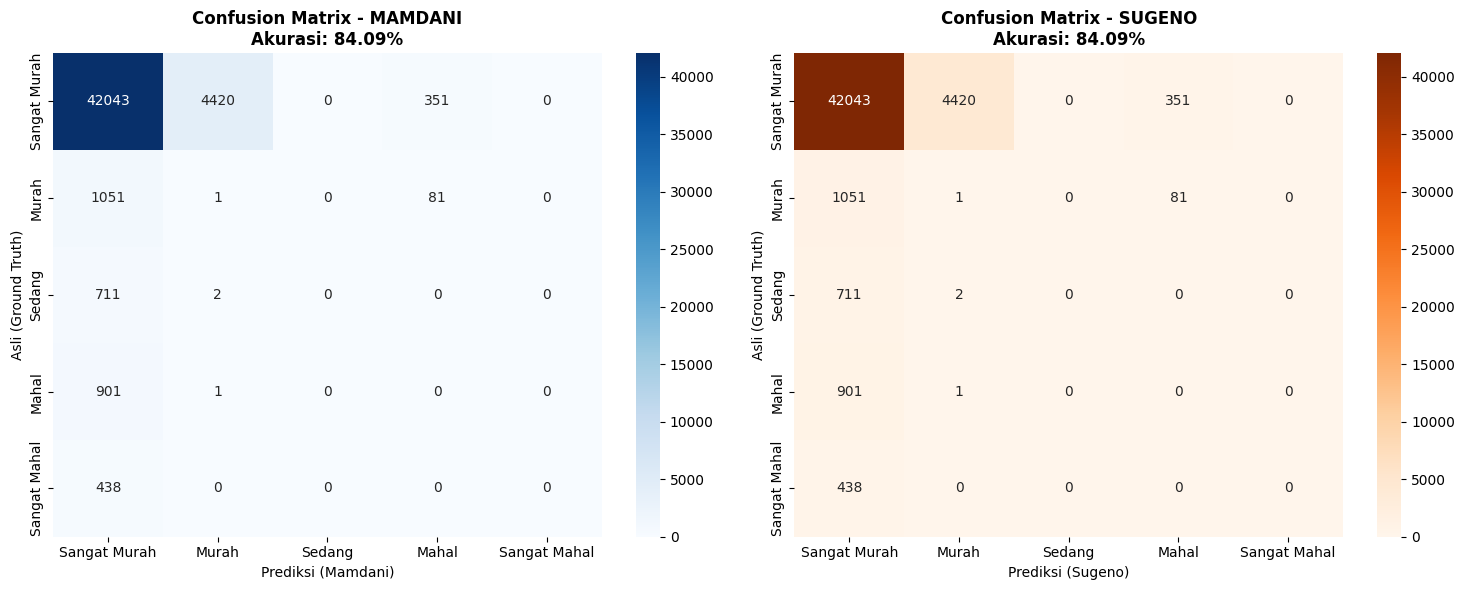

In [18]:
def get_crisp_category(price):
    cats = {
        'Sangat Murah': mf_price(price, 'Sangat Murah'),
        'Murah': mf_price(price, 'Murah'),
        'Sedang': mf_price(price, 'Sedang'),
        'Mahal': mf_price(price, 'Mahal'),
        'Sangat Mahal': mf_price(price, 'Sangat Mahal')
    }
    max_cat = max(cats, key=cats.get)
    if cats[max_cat] == 0:
        if price <= 3e5: return 'Sangat Murah'
        elif price >= 1.9e6: return 'Sangat Mahal'
    return max_cat

results = []

for idx, row in df.iterrows():
    actual = row['price']
    
    # Fuzzifikasi 5 Input
    f_a = fuzzify_area(row['Area_Marla'])
    f_bed = fuzzify_bed(row['bedrooms'])
    f_bath = fuzzify_bath(row['baths'])
    f_prop = fuzzify_prop(row['Property_Score'])
    f_loc = fuzzify_loc(row['Location_Score'])
    
    # Inferensi 20 Rules
    agg = eval_rules(f_a, f_bed, f_bath, f_prop, f_loc)
    
    # Defuzzifikasi
    m_pred = defuzz_mamdani_manual(agg)
    s_pred = defuzz_sugeno(agg)
    
    # Rekam hasil klasifikasi
    results.append({
        'Kategori Asli': get_crisp_category(actual),
        'Mamdani Kategori': get_crisp_category(m_pred),
        'Sugeno Kategori': get_crisp_category(s_pred)
    })

res_df = pd.DataFrame(results)
print("Eksekusi selesai!\n")

y_true = res_df['Kategori Asli'].tolist()
y_pred_mamdani = res_df['Mamdani Kategori'].tolist()
y_pred_sugeno = res_df['Sugeno Kategori'].tolist()

acc_mamdani = accuracy_score(y_true, y_pred_mamdani) * 100
acc_sugeno = accuracy_score(y_true, y_pred_sugeno) * 100

print("="*50)
print("=== HASIL AKURASI KLASIFIKASI KATEGORI ===")
print("="*50)
print(f"Akurasi MAMDANI (Unoptimized) : {acc_mamdani:.2f}%")
print(f"Akurasi SUGENO                : {acc_sugeno:.2f}%\n")

# --- VISUALISASI CONFUSION MATRIX ---
labels = ['Sangat Murah', 'Murah', 'Sedang', 'Mahal', 'Sangat Mahal']
cm_mamdani = confusion_matrix(y_true, y_pred_mamdani, labels=labels)
cm_sugeno = confusion_matrix(y_true, y_pred_sugeno, labels=labels)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_mamdani, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title('Confusion Matrix - MAMDANI\nAkurasi: {:.2f}%'.format(acc_mamdani), fontweight='bold')
ax[0].set_xlabel('Prediksi (Mamdani)')
ax[0].set_ylabel('Asli (Ground Truth)')

sns.heatmap(cm_sugeno, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title('Confusion Matrix - SUGENO\nAkurasi: {:.2f}%'.format(acc_sugeno), fontweight='bold')
ax[1].set_xlabel('Prediksi (Sugeno)')
ax[1].set_ylabel('Asli (Ground Truth)')

plt.tight_layout()
plt.show()